In [1]:
import pandas as pd

df = pd.read_csv("../data/train.tsv", sep="\t", header=None, quoting=3)

df.columns = [
    "id", "label", "statement", "subject", "speaker", "job", "state", "party",
    "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts",
    "pants_on_fire_counts", "context"
]

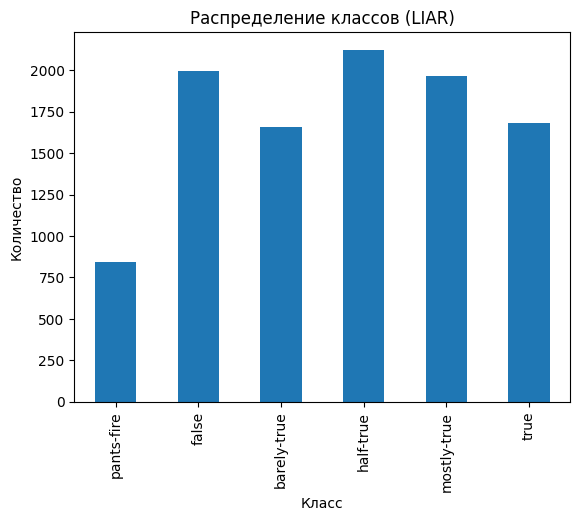

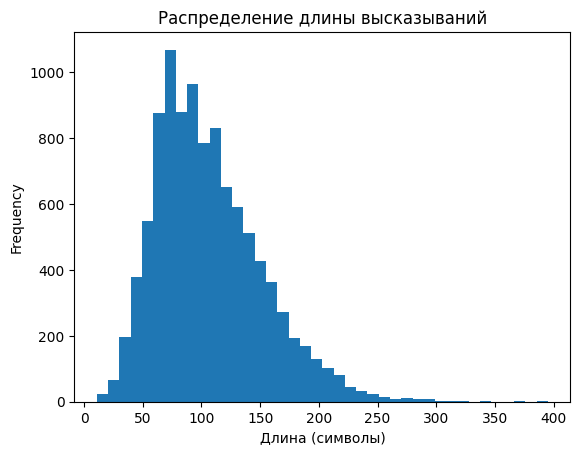

In [2]:
import matplotlib.pyplot as plt

ax = df['label'].value_counts().reindex(["pants-fire","false","barely-true","half-true","mostly-true","true"]).plot(kind='bar')
ax.set_title("Распределение классов (LIAR)")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество")
plt.show()

df['text_length'] = df['statement'].astype(str).str.len()
ax = df['text_length'].plot(kind='hist', bins=40)
ax.set_title("Распределение длины высказываний")
ax.set_xlabel("Длина (символы)")
plt.show()


In [3]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/doncheck/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

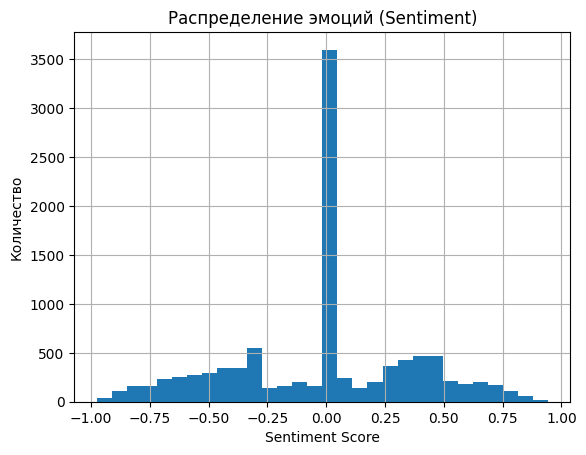

In [4]:
# Analyzing the sentiment of statements in the dataset using the VADER sentiment analysis tool.
# The 'compound' score ranges from -1 (negative) to 1 (positive), with 0 being neutral.

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['statement'].apply(lambda x: sia.polarity_scores(x)['compound'])

ax = df['sentiment'].hist(bins=30)
ax.set_title('Распределение эмоций (Sentiment)')
ax.set_xlabel('Sentiment Score')
ax.set_ylabel('Количество')
plt.show()

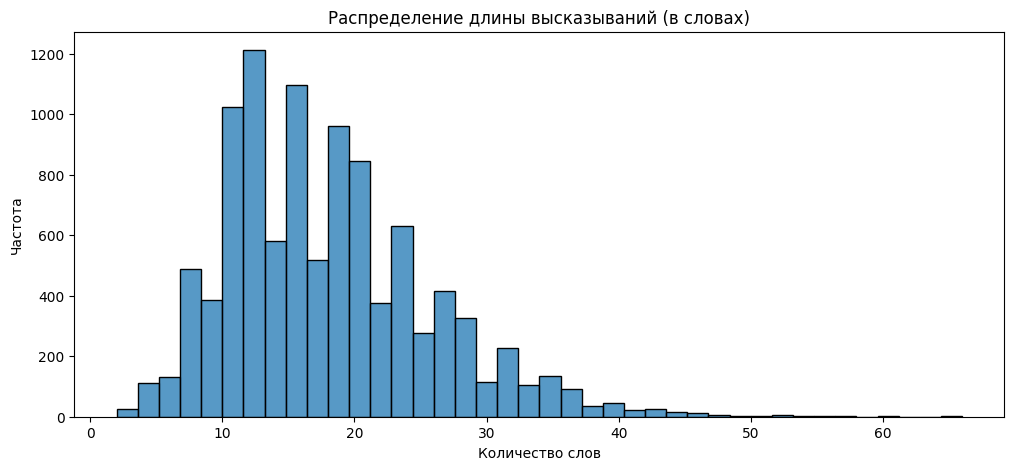

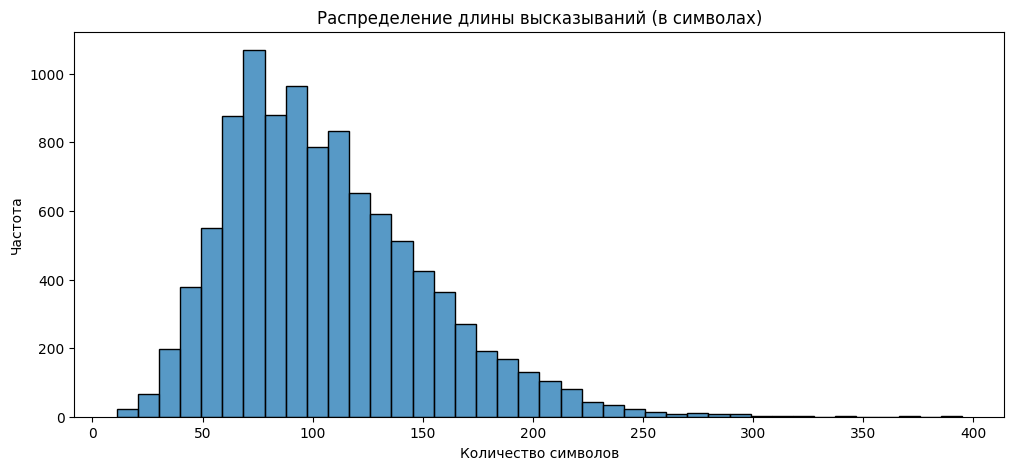

label
false          16.792292
pants-fire     17.135392
true           17.898396
barely-true    18.146651
mostly-true    18.226348
half-true      18.783797
Name: len_words, dtype: float64

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Добавим длины в слова и символы
df['len_words'] = df['statement'].apply(lambda x: len(str(x).split()))
df['len_chars'] = df['statement'].apply(lambda x: len(str(x)))

plt.figure(figsize=(12,5))
sns.histplot(df['len_words'], bins=40, kde=False)
plt.title("Распределение длины высказываний (в словах)")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['len_chars'], bins=40, kde=False)
plt.title("Распределение длины высказываний (в символах)")
plt.xlabel("Количество символов")
plt.ylabel("Частота")
plt.show()

# Средняя длина по каждому классу
df.groupby('label')['len_words'].mean().sort_values()


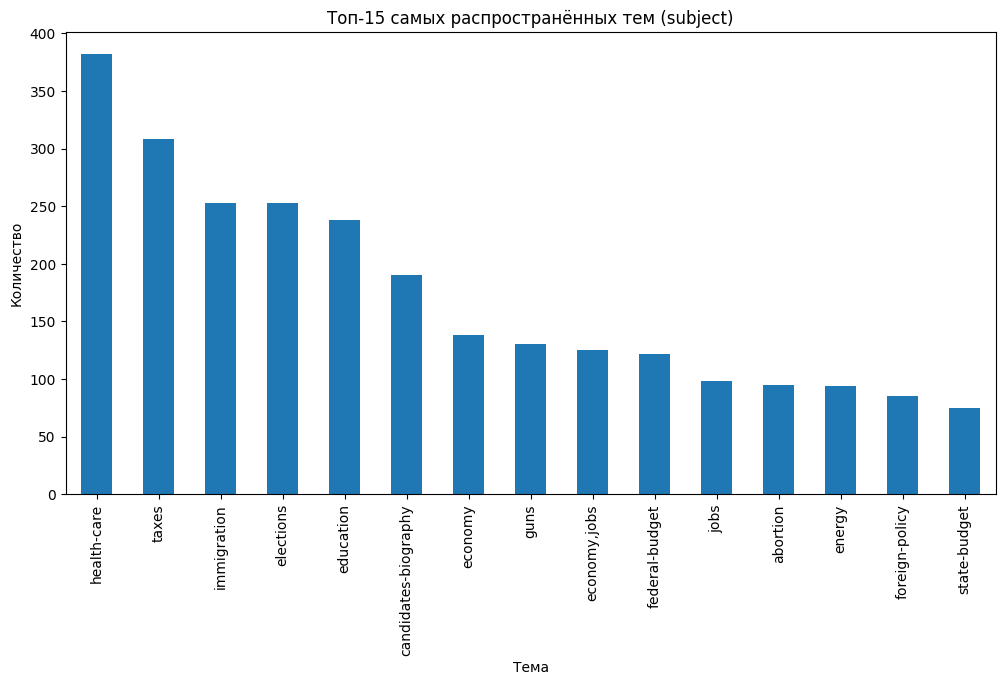

In [7]:
plt.figure(figsize=(12,6))
df['subject'].value_counts().head(15).plot(kind='bar')
plt.title("Топ-15 самых распространённых тем (subject)")
plt.xlabel("Тема")
plt.ylabel("Количество")
plt.show()

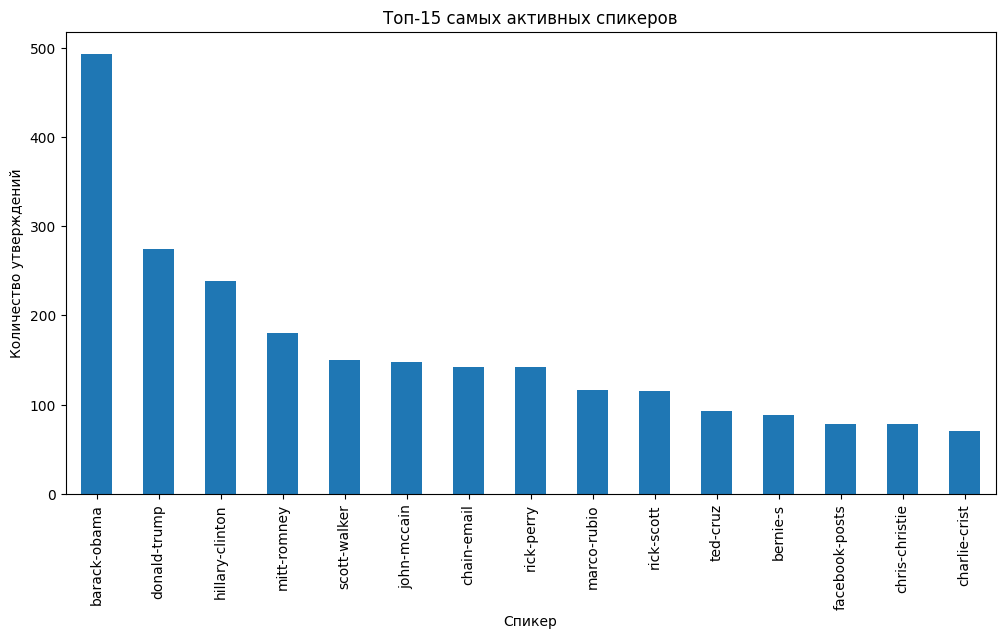

In [8]:
plt.figure(figsize=(12,6))
df['speaker'].value_counts().head(15).plot(kind='bar')
plt.title("Топ-15 самых активных спикеров")
plt.xlabel("Спикер")
plt.ylabel("Количество утверждений")
plt.show()

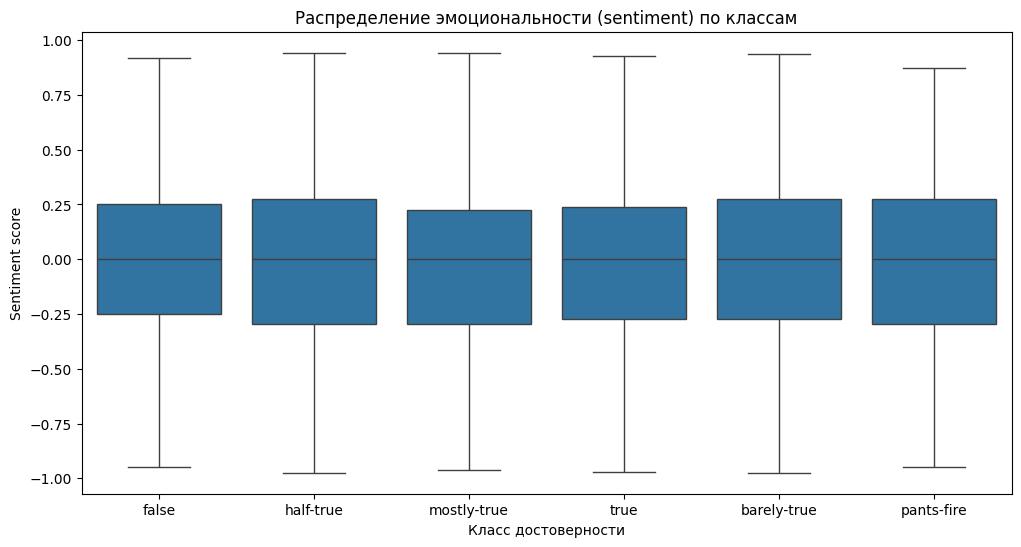

label
barely-true    0.000716
false         -0.007140
half-true     -0.020658
mostly-true   -0.029053
pants-fire    -0.009597
true          -0.014155
Name: sentiment, dtype: float64

In [9]:
# sentiment уже должен быть посчитан ранее как vader_score
# если нет — запускаем:

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['statement'].apply(lambda x: sia.polarity_scores(x)['compound'])

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='label', y='sentiment')
plt.title("Распределение эмоциональности (sentiment) по классам")
plt.xlabel("Класс достоверности")
plt.ylabel("Sentiment score")
plt.show()

df.groupby('label')['sentiment'].mean()
